# Capstone project 
##### The problem: A bank loses money every time a customer closes their account (Exited). Acquiring a new customer costs far more than retaining an existing one — so the bank wants to predict which customers are at risk of leaving, before they leave, so the retention team can proactively intervene (better rates, personalized outreach, etc.)

# Import libabries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os







print(os.getcwd())

c:\Users\Edward\daily-ds\deep-learning


# Load data 

In [17]:
df = pd.read_csv('../ml/data/Bank Customer Churn Prediction.csv')
print(df.info())
print(df.describe())

# check for any na or empty rows
#df.isnull().sum()
#df.isna().sum()
# no empty or na rows

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   
mean 

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# EDA

### Inspect Churn distribution 

Number of customers who churned: 2037
NUmber of customers who did not churned: 7963
Churn rate: 20.37%


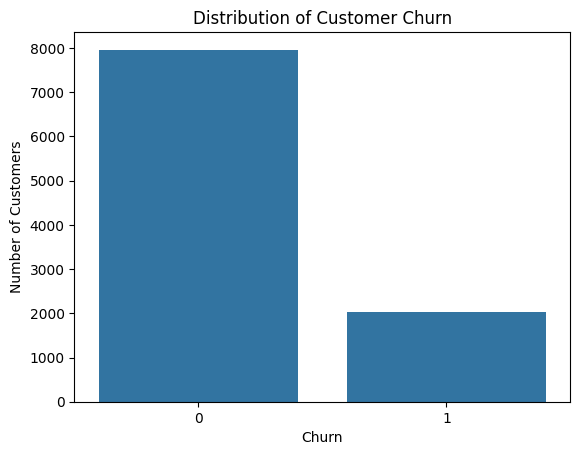

In [ ]:
print(f"Number of customers who churned: {(df['churn']==1).sum()}")
print(f"NUmber of customers who did not churned: {(df['churn']==0).sum()}")
churn_rate = (df['churn'].sum()/len(df)) *100
print(f"Churn rate: {churn_rate:.2f}%")


sns.countplot(data = df, x="churn")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Inspecting Age vs churn

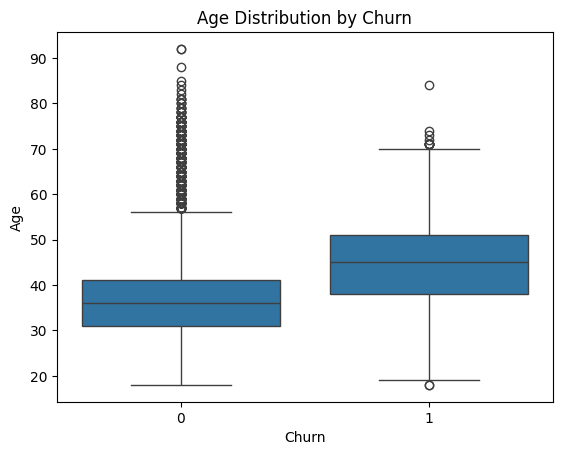

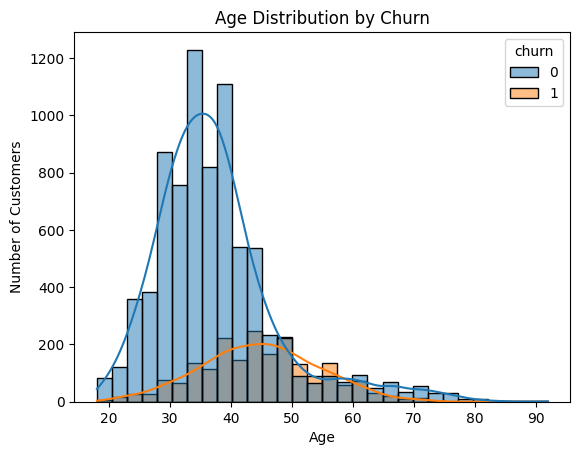

In [30]:
sns.boxplot(data=df, x="churn", y="age")

plt.title("Age Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Age")
plt.show()

sns.histplot(
    data=df,
    x="age",
    hue="churn",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Churn")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

### Gender vs Churn

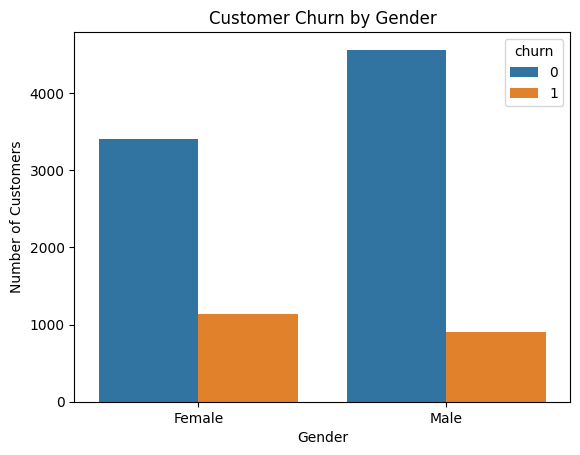

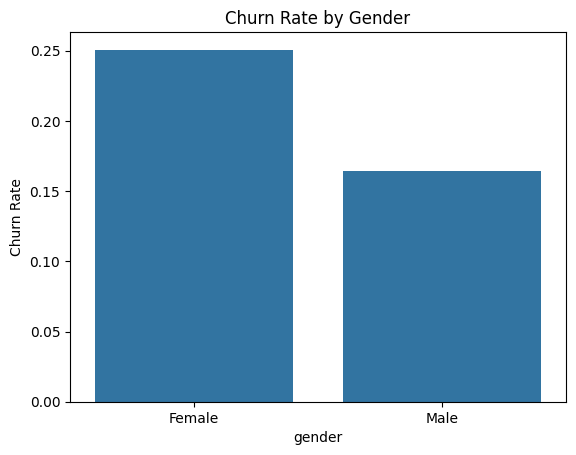

In [36]:
sns.countplot(
    data=df,
    x="gender",
    hue="churn"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

gender_churn = df.groupby("gender")["churn"].mean().reset_index()

sns.barplot(
    data=gender_churn,
    x="gender",
    y="churn"
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate by Gender")
plt.show()